# NB05 — Comparación de Resultados
**Proyecto:** Clasificación de Marcha Patológica

**Autor:** Weimar Andres Arenas Gonzalez  
**Curso:** Fundamentos de Deep Learning

---

Compara los modelos entrenados (SimpleRNN, LSTM, GRU) con las referencias del paper (Jun et al., 2020).

**Prerequisitos:**
- Ejecutar NB03 (`Arquitectura_linea_base_RNN.ipynb`) → genera `cache/results_rnn.pkl`
- Ejecutar NB04 (`LSTM_GRU.ipynb`) → genera `results_lstm_gru.pkl`

**Referencias del paper (Jun et al., 2020):**
| Modelo | Accuracy LOSO-CV |
|--------|------------------|
| RNN (todos joints) | 86.23% |
| LSTM (todos joints) | 87.25% |
| GRU (todos joints) | 90.13% |
| GRU (solo piernas) | **93.67%** ← Mejor resultado |

In [11]:
import sys
if sys.version_info >= (3, 13):
    v = f'{sys.version_info.major}.{sys.version_info.minor}'
    raise EnvironmentError(
        f'Python {v} no es compatible con TensorFlow. '
        'Usa Google Colab o cambia el kernel a Python 3.10-3.12.'
    )
import subprocess
pkgs = ['numpy','pandas','matplotlib','seaborn','scikit-learn']
subprocess.run([sys.executable,'-m','pip','install','-q']+pkgs,
               capture_output=True, timeout=300)
print(f'Python {sys.version_info.major}.{sys.version_info.minor} - OK')


Python 3.10 - OK


In [12]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
%matplotlib inline
plt.rcParams['figure.figsize'] = (13, 5)
sns.set_style('whitegrid')

CLASS_NAMES = ['Normal','Antalgic','Stiff-leg','Lurching','Steppage','Trendelenburg']
N_CLASSES   = 6
os.makedirs('figuras/NB05', exist_ok=True)
print('Imports OK')

Imports OK


## 1. Cargar resultados

In [13]:
def load_results_safe(path):
    """Busca el archivo en varias rutas posibles."""
    for p in [path, os.path.basename(path), 
              os.path.join('cache', os.path.basename(path))]:
        if os.path.exists(p):
            with open(p, 'rb') as f:
                r = pickle.load(f)
            print(f'Cargado: {p}')
            return r
    print(f'  Advertencia: {path} no encontrado (ejecutar notebook correspondiente primero)')
    return None

results_rnn      = load_results_safe('cache/results_rnn.pkl')
results_lstm_gru = load_results_safe('results_lstm_gru.pkl')  # NB04 guarda en root

PAPER_REFS = {
    'RNN\n(paper)':       86.23,
    'LSTM\n(paper)':      87.25,
    'GRU\n(paper)':       90.13,
    'GRU+Legs\n(paper)':  93.67,
}
print('Referencias OK')

Cargado: cache/results_rnn.pkl
Cargado: results_lstm_gru.pkl
Referencias OK


## 2. Extraccion de accuracy por modelo

In [14]:
def extract_acc(results, model_key):
    """
    Extrae la lista de accuracies de los resultados guardados.
    Los resultados tienen la estructura:
    { 'ModelName': {'accuracies': [0.68, 0.84, ...], 'mean_acc': 0.75, ...} }
    """
    if results is None:
        return None
    for k in results:
        if model_key.lower() in k.lower():
            entry = results[k]
            # Formato nuevo: dict con clave 'accuracies'
            if isinstance(entry, dict) and 'accuracies' in entry:
                return entry['accuracies']
            # Formato antiguo: lista de dicts por fold
            elif isinstance(entry, list):
                accs = []
                for fold in entry:
                    if isinstance(fold, dict):
                        accs.append(fold.get('test_acc', fold.get('accuracy', 0)))
                    else:
                        accs.append(fold)
                return accs
    return None

if results_rnn:
    print('results_rnn keys:', list(results_rnn.keys()))
if results_lstm_gru:
    print('results_lstm_gru keys:', list(results_lstm_gru.keys()))

results_rnn keys: ['SimpleRNN_AllJoints', 'SimpleRNN_LegsOnly']
results_lstm_gru keys: ['GRU-4L (todos)', 'GRU-4L (piernas)', 'LSTM-4L (todos)', 'LSTM-4L (piernas)']


## 3. Tabla resumen de resultados

In [15]:
# Mapeo de claves: (patrón_busqueda, etiqueta_display, archivo_resultados)
# Las claves reales son: 'SimpleRNN_AllJoints', 'SimpleRNN_LegsOnly', 
#                        'LSTM-4L (todos)', 'GRU-4L (todos)', 'GRU-4L (piernas)'
MODEL_KEYS = [
    ('alljoints', 'SimpleRNN (todos joints)', results_rnn),
    ('legsonly', 'SimpleRNN (solo piernas)', results_rnn),
    ('lstm-4l', 'LSTM-4L (todos joints)', results_lstm_gru),
    ('gru-4l (todos)', 'GRU-4L (todos joints)', results_lstm_gru),
    ('gru-4l (piernas)', 'GRU-4L (solo piernas)', results_lstm_gru),
]

rows = []
for ref_lbl, ref_acc in PAPER_REFS.items():
    rows.append({'Modelo': ref_lbl.replace('\n',' '), 'Acc. media (%)': f'{ref_acc:.2f}',
                 'Std (%)': '-', 'Fuente': 'Jun et al. 2020'})

for key, lbl, res in MODEL_KEYS:
    accs = extract_acc(res, key)
    if accs:
        mean = np.mean(accs) * 100
        std  = np.std(accs)  * 100
        rows.append({'Modelo': lbl, 'Acc. media (%)': f'{mean:.2f}',
                     'Std (%)': f'{std:.2f}', 'Fuente': 'Este trabajo'})
    else:
        rows.append({'Modelo': lbl, 'Acc. media (%)': 'N/A',
                     'Std (%)': '-', 'Fuente': 'Este trabajo'})

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))
df_summary

                  Modelo Acc. media (%) Std (%)          Fuente
             RNN (paper)          86.23       - Jun et al. 2020
            LSTM (paper)          87.25       - Jun et al. 2020
             GRU (paper)          90.13       - Jun et al. 2020
        GRU+Legs (paper)          93.67       - Jun et al. 2020
SimpleRNN (todos joints)          68.29   12.47    Este trabajo
SimpleRNN (solo piernas)          65.10    8.08    Este trabajo
  LSTM-4L (todos joints)          76.65   14.23    Este trabajo
   GRU-4L (todos joints)          79.19   12.61    Este trabajo
   GRU-4L (solo piernas)          87.63    8.93    Este trabajo


,Modelo,Acc. media (%),Std (%),Fuente
0,RNN (paper),86.23,-,Jun et al. 2020
1,LSTM (paper),87.25,-,Jun et al. 2020
2,GRU (paper),90.13,-,Jun et al. 2020
3,GRU+Legs (paper),93.67,-,Jun et al. 2020
4,SimpleRNN (todos joints),68.29,12.47,Este trabajo
5,SimpleRNN (solo piernas),65.10,8.08,Este trabajo
6,LSTM-4L (todos joints),76.65,14.23,Este trabajo
7,GRU-4L (todos joints),79.19,12.61,Este trabajo
8,GRU-4L (solo piernas),87.63,8.93,Este trabajo


## 4. Grafica de comparacion

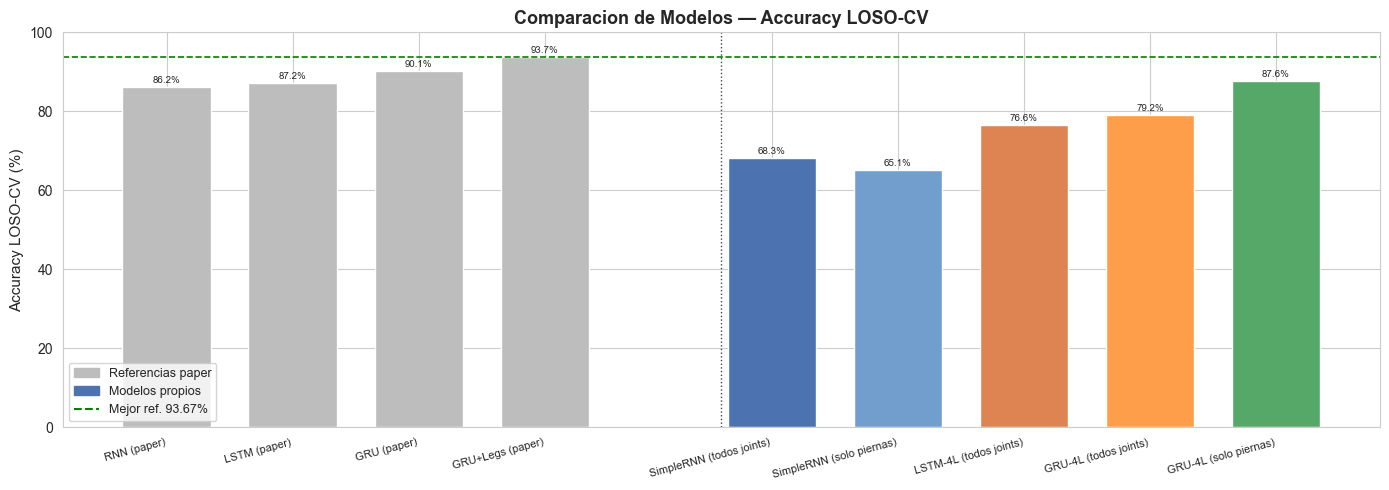

Guardado: figuras/NB05/comparacion_modelos.png


In [16]:
ref_labels = [k.replace('\n',' ') for k in PAPER_REFS]
ref_accs   = list(PAPER_REFS.values())

own_labels, own_accs = [], []
colors = ['#4c72b0','#729ece','#dd8452','#ff9e4a','#55a868','#88d498']
for key, lbl, res in MODEL_KEYS:
    accs = extract_acc(res, key)
    own_labels.append(lbl)
    if accs and len(accs) > 0:
        own_accs.append(np.mean(accs) * 100)
    else:
        own_accs.append(0)

fig, ax = plt.subplots(figsize=(14, 5))
x_ref = np.arange(len(ref_labels))
x_own = np.arange(len(own_labels)) + len(ref_labels) + 0.8

bars_r = ax.bar(x_ref, ref_accs, color='#bdbdbd', edgecolor='white', width=0.7)
bars_o = ax.bar(x_own, own_accs, color=colors[:len(own_labels)], edgecolor='white', width=0.7)
ax.axhline(93.67, color='green', linestyle='--', linewidth=1.2, label='Mejor ref. paper (93.67%)')
ax.axvline(len(ref_labels)+0.4, color='#444', linestyle=':', linewidth=1)

for bar in list(bars_r) + list(bars_o):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x()+bar.get_width()/2, h+0.5, f'{h:.1f}%',
                ha='center', va='bottom', fontsize=7)

ax.set_ylim(0, 100)
ax.set_ylabel('Accuracy LOSO-CV (%)', fontsize=11)
ax.set_title('Comparacion de Modelos — Accuracy LOSO-CV', fontsize=13, fontweight='bold')
ax.set_xticks(np.concatenate([x_ref, x_own]))
ax.set_xticklabels(ref_labels + own_labels, fontsize=8, rotation=15, ha='right')
ax.legend(fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#bdbdbd', label='Referencias paper'),
    Patch(color='#4c72b0', label='Modelos propios'),
    plt.Line2D([0],[0], color='green', linestyle='--', label='Mejor ref. 93.67%')
], fontsize=9)
plt.tight_layout()
plt.savefig('figuras/NB05/comparacion_modelos.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado: figuras/NB05/comparacion_modelos.png')

## 5. Boxplot de accuracies por fold

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27020\3686771161.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,


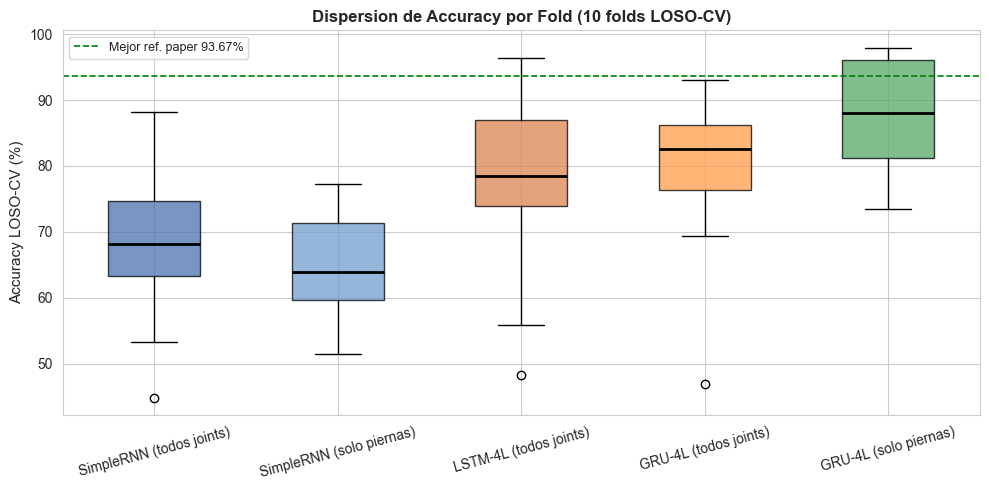

Guardado: figuras/NB05/boxplot_accuracies.png


In [17]:
box_data, box_labels = [], []
box_colors = []
for (key, lbl, res), col in zip(MODEL_KEYS, colors):
    accs = extract_acc(res, key)
    if accs and len(accs) > 0 and all(isinstance(a, (int, float)) for a in accs):
        if any(a > 0 for a in accs):
            box_data.append([a*100 for a in accs])
            box_labels.append(lbl)
            box_colors.append(col)

if box_data:
    fig, ax = plt.subplots(figsize=(10, 5))
    bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, col in zip(bp['boxes'], box_colors):
        patch.set_facecolor(col); patch.set_alpha(0.75)
    ax.axhline(93.67, color='green', linestyle='--', linewidth=1.2, label='Mejor ref. paper 93.67%')
    ax.set_ylabel('Accuracy LOSO-CV (%)', fontsize=11)
    ax.set_title('Dispersion de Accuracy por Fold (10 folds LOSO-CV)', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('figuras/NB05/boxplot_accuracies.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('Guardado: figuras/NB05/boxplot_accuracies.png')
else:
    print('Sin datos suficientes para el boxplot')

## 6. Conclusiones

In [18]:
print('='*55)
print('RESUMEN FINAL')
print('='*55)
for key, lbl, res in MODEL_KEYS:
    accs = extract_acc(res, key)
    if accs and len(accs) > 0:
        val = f'{np.mean(accs)*100:.2f}%'
    else:
        val = 'N/A'
    print(f'  {lbl:30s}: {val}')
print()
print('Referencias (Jun et al., 2020):')
for lbl, acc in PAPER_REFS.items():
    print(f'  {lbl.replace(chr(10)," "):30s}: {acc:.2f}%')
print()
print('Figuras generadas en figuras/NB05/')

RESUMEN FINAL
  SimpleRNN (todos joints)      : 68.29%
  SimpleRNN (solo piernas)      : 65.10%
  LSTM-4L (todos joints)        : 76.65%
  GRU-4L (todos joints)         : 79.19%
  GRU-4L (solo piernas)         : 87.63%

Referencias (Jun et al., 2020):
  RNN (paper)                   : 86.23%
  LSTM (paper)                  : 87.25%
  GRU (paper)                   : 90.13%
  GRU+Legs (paper)              : 93.67%

Figuras generadas en figuras/NB05/
